In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import joblib

In [4]:
# Đường dẫn tới tệp CSV
file_path = '../Data/AAPL.csv'

# Đọc CSV, bỏ qua 2 hàng đầu (Ticker và Date NaN)
df = pd.read_csv(file_path, skiprows=2)

# Đặt tên cột thủ công (dựa trên cấu trúc file)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Chuyển Date thành datetime và set làm index
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.set_index('Date', inplace=True)

# Kiểm tra DataFrame sau xử lý (tùy chọn)
print(df.head())  # Nên hiển thị dữ liệu từ 1980-12-12
print(df.tail())  # Kiểm tra ngày cuối
df.info()  # Xem số hàng và kiểu dữ liệu

               Close      High       Low      Open     Volume
Date                                                         
1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600
1980-12-15  0.093453  0.093881  0.093453  0.093881  175884800
1980-12-16  0.086594  0.087022  0.086594  0.087022  105728000
1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600
1980-12-18  0.091310  0.091738  0.091310  0.091310   73449600
                 Close        High         Low        Open    Volume
Date                                                                
2025-07-15  209.110001  211.889999  208.919998  209.220001  42296300
2025-07-16  210.160004  212.399994  208.639999  210.300003  47490500
2025-07-17  210.020004  211.800003  209.589996  210.570007  48068100
2025-07-18  211.179993  211.789993  209.699997  210.869995  48974600
2025-07-21  212.479996  215.779999  211.630005  212.100006  51322500
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11241 entries, 1980-12-12 to 2

In [5]:
# Tạo thư mục lưu kết quả và model
output_dir = '../'  # This points to the parent folder
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

output_dir_result = os.path.join(output_dir, 'Result/')
if not os.path.exists(output_dir_result):
    os.makedirs(output_dir_result, exist_ok=True)

output_dir_models = os.path.join(output_dir, 'Models/')
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models, exist_ok=True)

In [6]:
# Tạo features
df['Price_Diff'] = df['High'] - df['Low']
df['Avg_Price'] = (df['High'] + df['Low']) / 2
df['Volume_Ratio'] = df['Volume'] / df['Volume'].mean()

# Chọn features và target
features = ['Open', 'High', 'Low', 'Volume', 'Price_Diff', 'Avg_Price', 'Volume_Ratio']
X = df[features]
y = df['Close']

# Chia dữ liệu thành train và test (80% train, 20% test, giữ thứ tự thời gian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Khởi tạo và train mô hình Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự đoán trên tập test
model_predictions = model.predict(X_test)

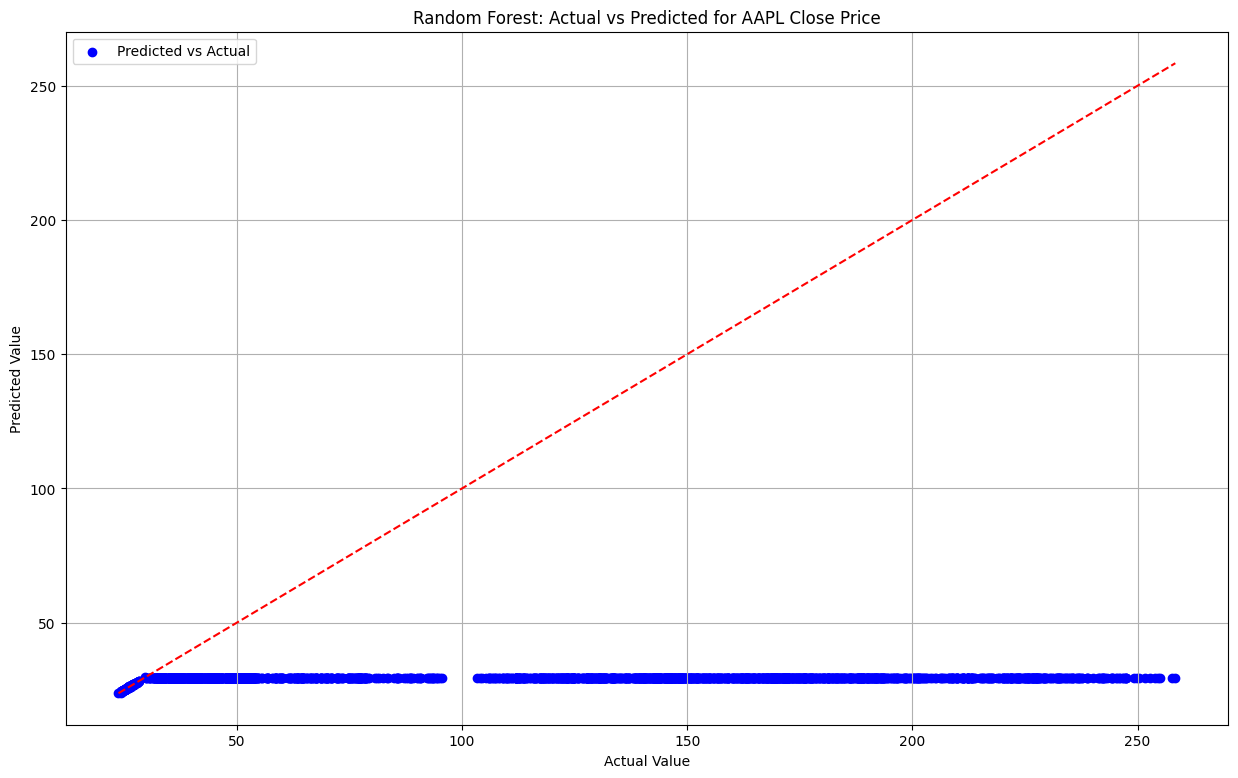

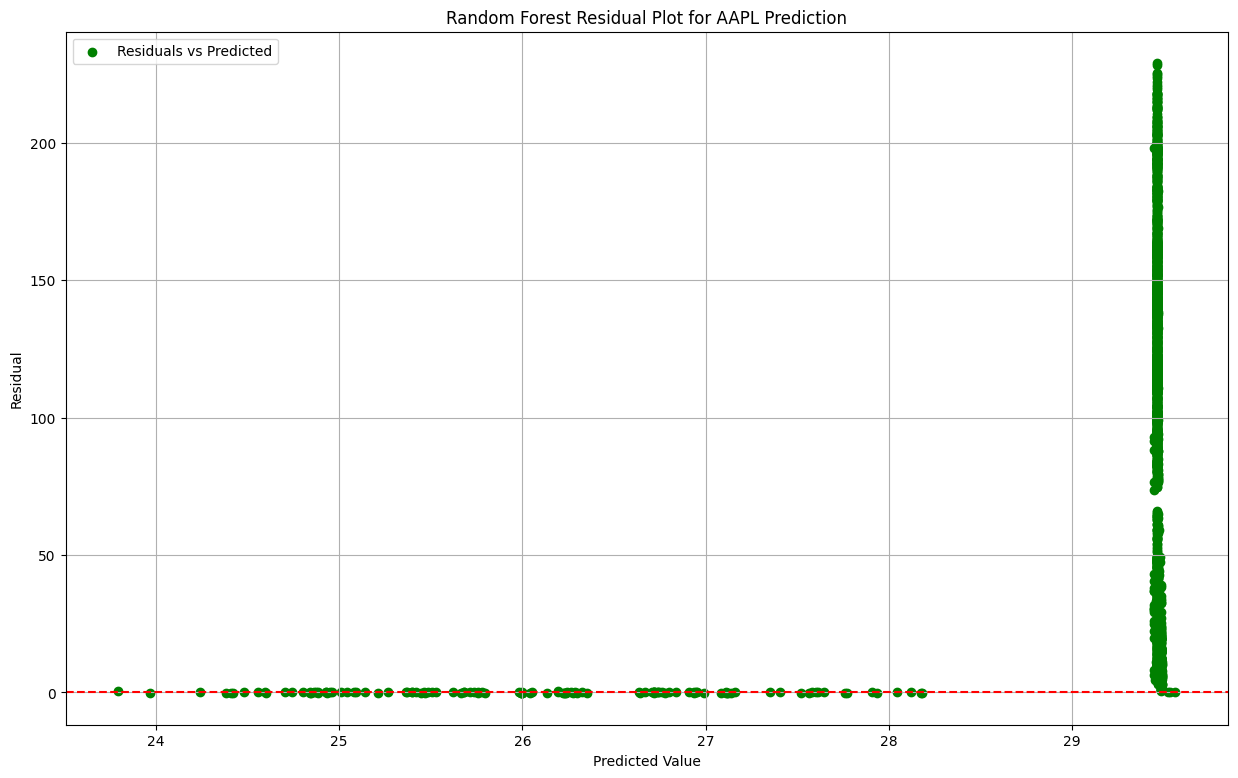

In [7]:
# Tính residuals
residuals = y_test - model_predictions

# Vẽ scatter plot: actual vs predicted
plt.figure(figsize=(15,9))
plt.grid()
plt.scatter(y_test, model_predictions, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Random Forest: Actual vs Predicted for AAPL Close Price')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.savefig(os.path.join(output_dir_result, 'rf_aapl_actual_vs_predicted.png'), dpi=300, bbox_inches='tight')
plt.show()

# Vẽ residual plot: residuals vs predicted
plt.figure(figsize=(15,9))
plt.grid()
plt.scatter(model_predictions, residuals, color='green', label='Residuals vs Predicted')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Random Forest Residual Plot for AAPL Prediction')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.legend()
plt.savefig(os.path.join(output_dir_result, 'rf_aapl_residual_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Tính metrics
mape = np.mean(np.abs(y_test - model_predictions) / np.abs(y_test))  # MAPE thủ công
mae = mean_absolute_error(y_test, model_predictions)
mse = mean_squared_error(y_test, model_predictions)
rmse = math.sqrt(mse)

# Tạo DataFrame so sánh
results_df = pd.DataFrame({
    'Date': y_test.index,
    'Predicted': model_predictions,
    'Actual': y_test
})

# Thêm metrics vào DataFrame
results_df['MAPE'] = mape
results_df['MAE'] = mae
results_df['MSE'] = mse
results_df['RMSE'] = rmse

# Save CSV vào output_dir_result
results_df.to_csv(os.path.join(output_dir_result, 'rf_aapl_predictions_and_metrics.csv'), index=False)

# In metrics để kiểm tra
print('Random Forest Mean Absolute Percentage Error:', mape)
print('Random Forest Mean Squared Error:', mse)
print('Random Forest Root Mean Squared Error:', rmse)
print('Random Forest Mean Absolute Error:', mae)

Random Forest Mean Absolute Percentage Error: 0.5911960351471804
Random Forest Mean Squared Error: 11586.121452359243
Random Forest Root Mean Squared Error: 107.6388473199116
Random Forest Mean Absolute Error: 84.44828598627149


In [9]:
# Save model vào output_dir_models
joblib.dump(model, os.path.join(output_dir_models, 'rf_aapl_model.pkl'))
print("Random Forest model saved successfully.")

Random Forest model saved successfully.
